In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
print(df.columns)
print(df.info())
print(df['OnlineSecurity'].unique())
print(df['TechSupport'].unique())
print(df['Partner'].unique())
print(df['Dependents'].unique())
print(df['PhoneService'].unique())
print(df['MultipleLines'].unique())
print(df['OnlineBackup'].unique())
print(df['DeviceProtection'].unique())
print(df['StreamingTV'].unique())
print(df['StreamingMovies'].unique())
print(df['PaperlessBilling'].unique())
print(df['Churn'].unique())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

0:	learn: 0.6522329	test: 0.6528690	best: 0.6528690 (0)	total: 76.6ms	remaining: 1m 16s
100:	learn: 0.4207942	test: 0.4781401	best: 0.4754709 (69)	total: 921ms	remaining: 8.2s
200:	learn: 0.3669867	test: 0.4867299	best: 0.4754709 (69)	total: 1.81s	remaining: 7.21s
300:	learn: 0.3278246	test: 0.4975593	best: 0.4754709 (69)	total: 2.72s	remaining: 6.32s
400:	learn: 0.2962330	test: 0.5053966	best: 0.4754709 (69)	total: 3.6s	remaining: 5.37s
500:	learn: 0.2692029	test: 0.5194504	best: 0.4754709 (69)	total: 4.44s	remaining: 4.42s
600:	learn: 0.2469345	test: 0.5302805	best: 0.4754709 (69)	total: 5.26s	remaining: 3.49s
700:	learn: 0.2278544	test: 0.5397633	best: 0.4754709 (69)	total: 6.08s	remaining: 2.59s
800:	learn: 0.2101878	test: 0.5521939	best: 0.4754709 (69)	total: 6.91s	remaining: 1.72s
900:	learn: 0.1950452	test: 0.5619502	best: 0.4754709 (69)	total: 7.71s	remaining: 847ms
999:	learn: 0.1794412	test: 0.5700642	best: 0.4754709 (69)	total: 8.59s	remaining: 0us

bestTest = 0.4754709259
b

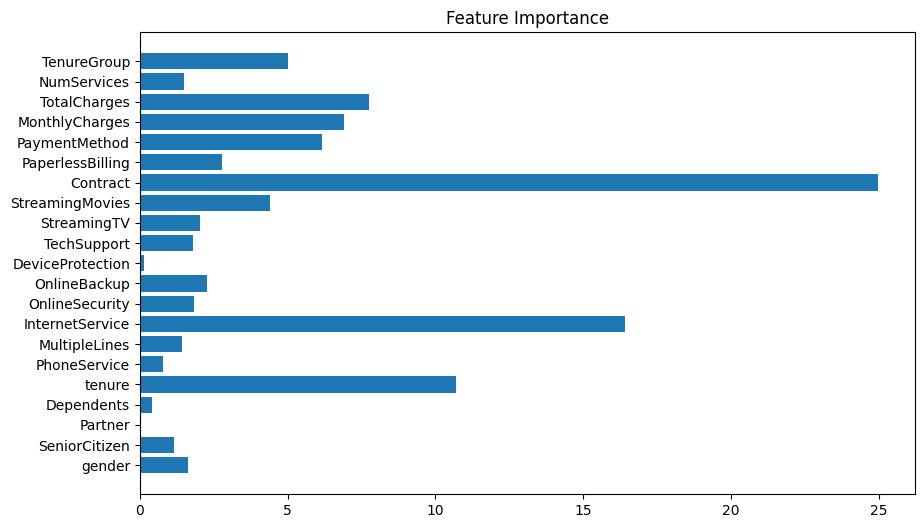


Sample Customer Segmentation (first 5 rows):
      ChurnProb RiskCategory
437    0.073149          Low
2280   0.874907         High
2235   0.118931          Low
4460   0.552184       Medium
3761   0.035725          Low


In [2]:
# ====== IMPORTS ======
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ====== LOAD DATA ======
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ====== PREPROCESSING ======
# TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ",0))

# Replace 'No internet service' or 'No phone service' with 'No'
replace_cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

# Binary mapping
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

# Feature engineering
df['NumServices'] = ((df['PhoneService']==1).astype(int) +
                     (df['MultipleLines']=='Yes').astype(int) +
                     (df['OnlineSecurity']=='Yes').astype(int) +
                     (df['OnlineBackup']=='Yes').astype(int) +
                     (df['DeviceProtection']=='Yes').astype(int) +
                     (df['TechSupport']=='Yes').astype(int) +
                     (df['StreamingTV']=='Yes').astype(int) +
                     (df['StreamingMovies']=='Yes').astype(int))

# Tenure group
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72], labels=[1,2,3,4,5])
df['TenureGroup'] = df['TenureGroup'].astype(str)

# CatBoost categorical features
cat_features = ['gender','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                'Contract','PaymentMethod','TenureGroup']

# ====== TRAIN-TEST SPLIT ======
X = df.drop(['customerID','Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

# ====== TRAIN CATBOOST ======
cb_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    class_weights=[1,2],  # Handle class imbalance
    random_seed=42,
    verbose=100
)
cb_model.fit(train_pool, eval_set=test_pool)

# ====== EVALUATION ======
y_pred = cb_model.predict(X_test)
y_prob = cb_model.predict_proba(X_test)[:,1]

print("\n📊 Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature importance plot
feat_imp = cb_model.get_feature_importance(train_pool)
plt.figure(figsize=(10,6))
plt.barh(X_train.columns, feat_imp)
plt.title("Feature Importance")
plt.show()

# ====== CUSTOMER SEGMENTATION DASHBOARD ======
X_test_copy = X_test.copy()
X_test_copy['ChurnProb'] = y_prob
X_test_copy['RiskCategory'] = pd.cut(y_prob, bins=[0,0.4,0.7,1], labels=['Low','Medium','High'])
print("\nSample Customer Segmentation (first 5 rows):")
print(X_test_copy[['ChurnProb','RiskCategory']].head())

# ====== SIMPLE UI ======
def get_input(prompt, options=None):
    while True:
        val = input(f"{prompt}: ")
        if options and val not in options:
            print(f"Enter valid option: {options}")
        else:
            return val

def predict_churn():
    print("\n--- Enter Customer Details ---")
    gender = get_input("Gender (Male/Female)", ['Male','Female'])
    senior = get_input("Senior Citizen? (Yes/No)", ['Yes','No'])
    partner = get_input("Partner? (Yes/No)", ['Yes','No'])
    dependents = get_input("Dependents? (Yes/No)", ['Yes','No'])
    tenure = int(get_input("Tenure (in months)"))
    phone = get_input("Phone Service? (Yes/No)", ['Yes','No'])
    multiple = get_input("Multiple Lines? (Yes/No)", ['Yes','No'])
    internet = get_input("Internet Service (DSL/Fiber/No)", ['DSL','Fiber','No'])
    contract = get_input("Contract Type (Month-to-month/One year/Two year)", ['Month-to-month','One year','Two year'])
    paperless = get_input("Paperless Billing? (Yes/No)", ['Yes','No'])
    payment = get_input("Payment Method (Electronic check/Mailed check/Bank transfer/Credit card)",
                        ['Electronic check','Mailed check','Bank transfer','Credit card'])
    monthly = float(get_input("Monthly Charges"))
    total = float(get_input("Total Charges"))
    
    # Services
    online_sec = get_input("Online Security? (Yes/No)", ['Yes','No'])
    online_bk = get_input("Online Backup? (Yes/No)", ['Yes','No'])
    device_prot = get_input("Device Protection? (Yes/No)", ['Yes','No'])
    tech_supp = get_input("Tech Support? (Yes/No)", ['Yes','No'])
    streaming_tv = get_input("Streaming TV? (Yes/No)", ['Yes','No'])
    streaming_movies = get_input("Streaming Movies? (Yes/No)", ['Yes','No'])
    
    num_services = sum([phone=='Yes', multiple=='Yes', online_sec=='Yes', online_bk=='Yes',
                        device_prot=='Yes', tech_supp=='Yes', streaming_tv=='Yes', streaming_movies=='Yes'])
    
    # Tenure group
    if tenure <=12: tenure_group='1'
    elif tenure<=24: tenure_group='2'
    elif tenure<=48: tenure_group='3'
    elif tenure<=60: tenure_group='4'
    else: tenure_group='5'
    
    input_df = pd.DataFrame([{
        'gender':gender,
        'SeniorCitizen':1 if senior=='Yes' else 0,
        'Partner':1 if partner=='Yes' else 0,
        'Dependents':1 if dependents=='Yes' else 0,
        'tenure':tenure,
        'PhoneService':1 if phone=='Yes' else 0,
        'MultipleLines':multiple,
        'InternetService':internet,
        'OnlineSecurity':online_sec,
        'OnlineBackup':online_bk,
        'DeviceProtection':device_prot,
        'TechSupport':tech_supp,
        'StreamingTV':streaming_tv,
        'StreamingMovies':streaming_movies,
        'Contract':contract,
        'PaperlessBilling':1 if paperless=='Yes' else 0,
        'PaymentMethod':payment,
        'MonthlyCharges':monthly,
        'TotalCharges':total,
        'NumServices':num_services,
        'TenureGroup':tenure_group
    }])
    
    pred_prob = cb_model.predict_proba(Pool(input_df, cat_features=cat_features))[0][1]
    pred = cb_model.predict(Pool(input_df, cat_features=cat_features))[0]
    
    # Risk category
    if pred_prob > 0.7: risk="High"
    elif pred_prob > 0.4: risk="Medium"
    else: risk="Low"
    
    print(f"\nPredicted Churn: {'Yes' if pred==1 else 'No'}")
    print(f"Churn Probability: {pred_prob*100:.2f}%")
    print(f"Risk Category: {risk}")
    
    # Business suggestion
    if risk=="High":
        print("Suggestion: Offer retention incentives or loyalty programs.")
    elif risk=="Medium":
        print("Suggestion: Engage customer with reminders or offers.")
    else:
        print("Suggestion: Maintain current service.")

# ====== TEST UI ======
# predict_churn()  # Uncomment to run in terminal


In [3]:
predict_churn()


--- Enter Customer Details ---


Gender (Male/Female):  Female
Senior Citizen? (Yes/No):  No
Partner? (Yes/No):  Yes
Dependents? (Yes/No):  No
Tenure (in months):  1
Phone Service? (Yes/No):  Yes
Multiple Lines? (Yes/No):  No
Internet Service (DSL/Fiber/No):  Fiber
Contract Type (Month-to-month/One year/Two year):  One year
Paperless Billing? (Yes/No):  Yes
Payment Method (Electronic check/Mailed check/Bank transfer/Credit card):  Electronic check
Monthly Charges:  100
Total Charges:  500
Online Security? (Yes/No):  Yes
Online Backup? (Yes/No):  No
Device Protection? (Yes/No):  Yes
Tech Support? (Yes/No):  Yes
Streaming TV? (Yes/No):  No
Streaming Movies? (Yes/No):  Yes



Predicted Churn: No
Churn Probability: 23.79%
Risk Category: Low
Suggestion: Maintain current service.
